In [1]:

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
nln_data_med = np.loadtxt(open('../waffle/data/nln/medium','rt').readlines()[:-1], skiprows=1, dtype=int)
waf_data_med = np.loadtxt(open('../waffle/data/waf/medium','rt').readlines()[:-1], skiprows=1, dtype=int)

nln_df_med = pd.DataFrame(nln_data_med, columns=["NlogN (M)"])
waf_df_med = pd.DataFrame(waf_data_med, columns=["Waffle (M)"])

med_df = pd.concat([nln_df_med, waf_df_med])

print(nln_df_med.describe().apply(lambda s: s.apply('{0:.5f}'.format)))
print(waf_df_med.describe().apply(lambda s: s.apply('{0:.5f}'.format)))

print(nln_df_med.quantile([0.25,0.5,0.75]))
print(waf_df_med.quantile([0.25,0.5,0.75]))

med_df.describe().apply(lambda s: s.apply('{0:.5f}'.format))

dfm = med_df.melt(var_name='cols', value_name='vals')

display(dfm)

             NlogN (M)
count       8759.00000
mean       68578.74792
std      1576987.41943
min          163.00000
25%          758.00000
50%         3227.00000
75%         5486.50000
max    145818495.00000
          Waffle (M)
count     9419.00000
mean     63704.76494
std     279995.71619
min        170.00000
25%        489.50000
50%        733.00000
75%        941.00000
max    1535600.00000
      NlogN (M)
0.25      758.0
0.50     3227.0
0.75     5486.5
      Waffle (M)
0.25       489.5
0.50       733.0
0.75       941.0


,cols,vals
0,NlogN (M),339.0
1,NlogN (M),315.0
2,NlogN (M),304.0
3,NlogN (M),310.0
4,NlogN (M),303.0
...,...,...
36351,Waffle (M),2156.0
36352,Waffle (M),534.0
36353,Waffle (M),353.0
36354,Waffle (M),348.0


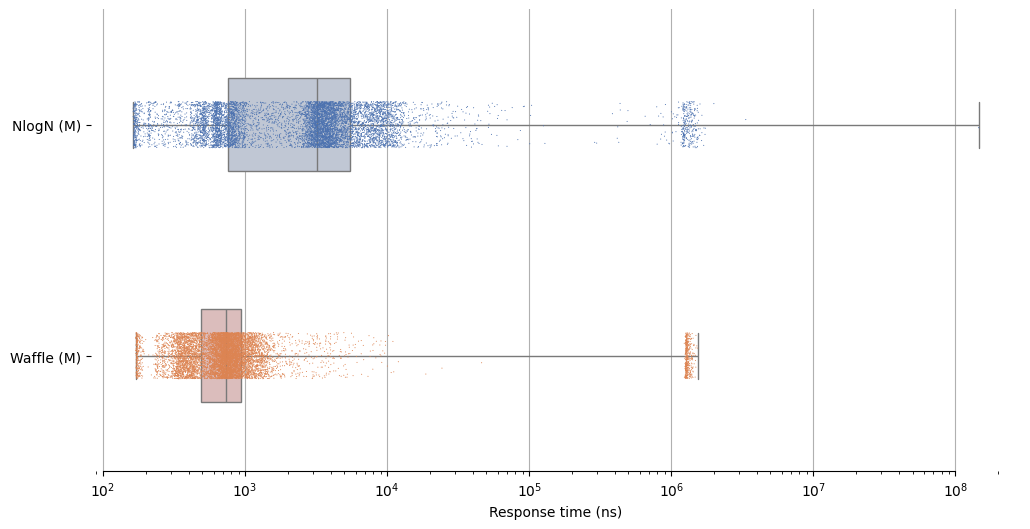

In [3]:


f, ax = plt.subplots(figsize=(12, 6))
ax.set_xscale("log")

sns.set_theme(style="ticks")
sns.boxplot()

sns.boxplot(
    data=dfm,x="vals", y="cols", hue="cols",
    whis=[0, 100], width=.4, palette="vlag"
)


ax.set(xlabel='Response time (ns)')

sns.stripplot(data=dfm, x="vals", y="cols", size=0.75, hue ="cols")

ax.xaxis.grid(True)
ax.set(ylabel="")
sns.despine(trim=True, left=True)


